In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

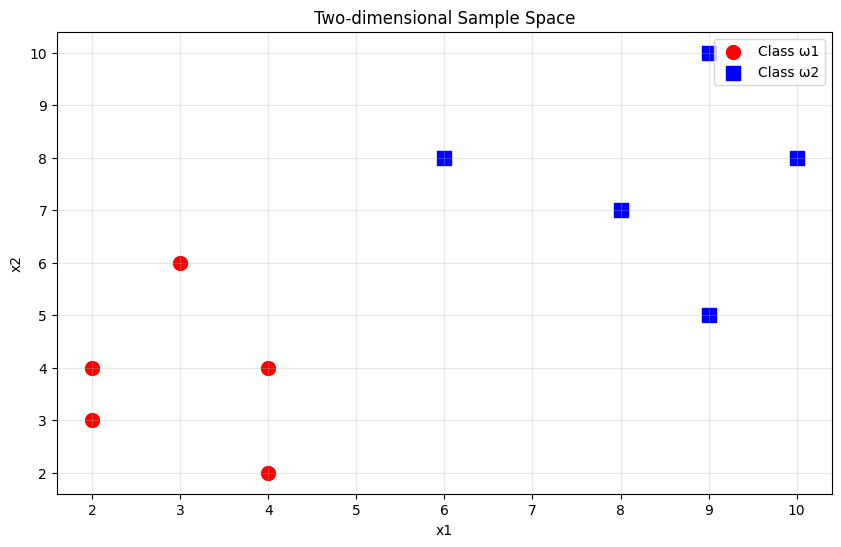

In [2]:
# Step 1: Define sample data for classes w1 and w2
X1 = np.array([[4, 2], [2, 4], [2, 3], [3, 6], [4, 4]])  # Class w1
X2 = np.array([[9, 10], [6, 8], [9, 5], [8, 7], [10, 8]])  # Class w2

# Visualize the data in 2D space
plt.figure(figsize=(10, 6))
plt.scatter(X1[:, 0], X1[:, 1], c='red', marker='o', s=100, label='Class ω1')
plt.scatter(X2[:, 0], X2[:, 1], c='blue', marker='s', s=100, label='Class ω2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Two-dimensional Sample Space')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Step 2: Compute class means
mu1 = np.mean(X1, axis=0)  # Mean of class w1
mu2 = np.mean(X2, axis=0)  # Mean of class w2

print("Class w1 mean:", mu1)
print("Class w2 mean:", mu2)

Class w1 mean: [3.  3.8]
Class w2 mean: [8.4 7.6]


In [4]:
# Step 3: Compute covariance matrices
S1 = np.cov(X1.T)  # Covariance matrix for class w1
S2 = np.cov(X2.T)  # Covariance matrix for class w2

print("Covariance matrix S1 (class w1):")
print(S1)
print("\nCovariance matrix S2 (class w2):")
print(S2)

Covariance matrix S1 (class w1):
[[ 1.   -0.25]
 [-0.25  2.2 ]]

Covariance matrix S2 (class w2):
[[ 2.3  -0.05]
 [-0.05  3.3 ]]


In [5]:
# Step 4: Calculate Within-class scatter matrix
SW = S1 + S2

print("Within-class scatter matrix SW:")
print(SW)

Within-class scatter matrix SW:
[[ 3.3 -0.3]
 [-0.3  5.5]]


In [6]:
# Step 5: Calculate Between-class scatter matrix
# SB = (mu1 - mu2) * (mu1 - mu2)T
mean_diff = (mu1 - mu2).reshape(-1, 1)
SB = mean_diff @ mean_diff.T

print("Between-class scatter matrix SB:")
print(SB)

Between-class scatter matrix SB:
[[29.16 20.52]
 [20.52 14.44]]


In [7]:
# Step 6 & 7: LDA projection and compute eigenvector W
# Calculate SW^(-1) * SB
SW_inv_SB = np.linalg.inv(SW) @ SB

# Find eigenvalues and eigenvectors
eigenvalues, eigenvectors = eig(SW_inv_SB)

# Get the largest eigenvector (corresponding to largest eigenvalue)
max_idx = np.argmax(eigenvalues)
W = eigenvectors[:, max_idx].real

print("Eigenvalues:", eigenvalues.real)
print("Largest eigenvector W:", W)

Eigenvalues: [ 1.22006645e+01 -1.35428903e-16]
Largest eigenvector W: [0.90878558 0.41726342]


In [8]:
# Step 8: Project samples onto the largest eigenvector
# Project class w1 samples
Y1 = X1 @ W

# Project class w2 samples  
Y2 = X2 @ W

print("Projected samples for class w1:", Y1)
print("Projected samples for class w2:", Y2)

Projected samples for class w1: [4.46966918 3.48662485 3.06936143 5.22993727 5.30419602]
Projected samples for class w2: [12.35170446  8.79082087 10.26538736 10.19112861 12.4259632 ]


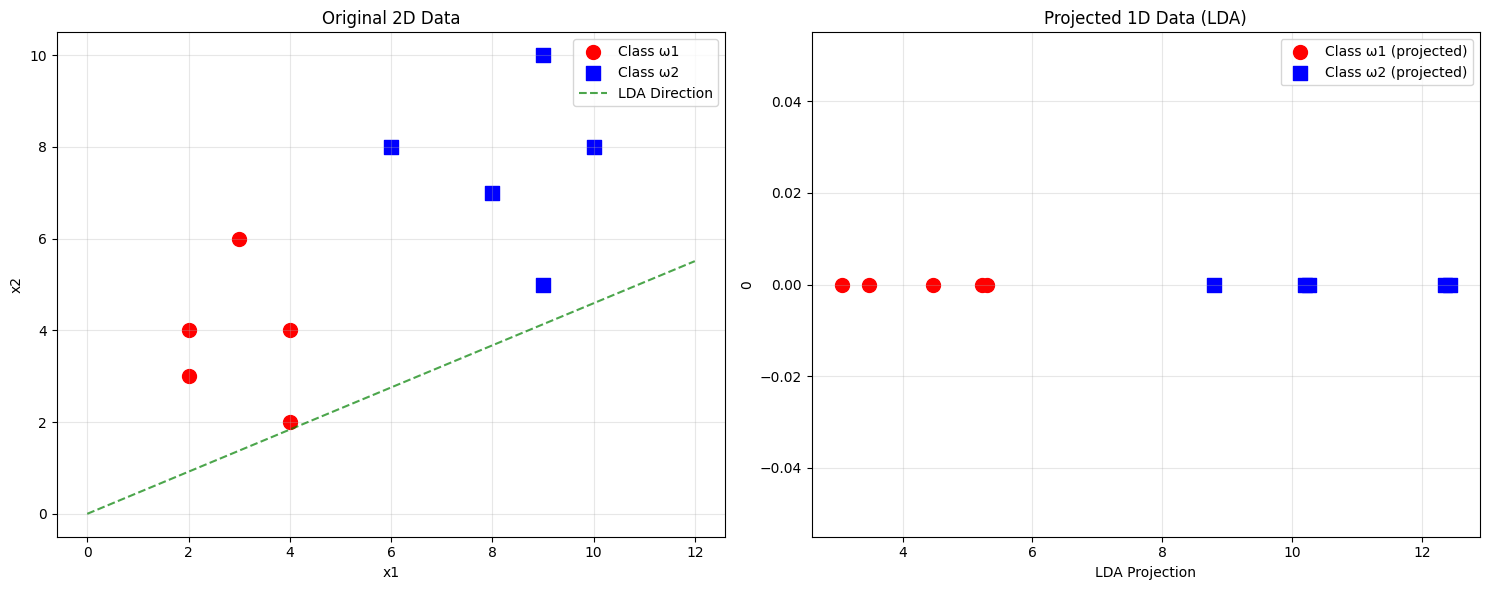


=== LDA Results Summary ===
Original data dimension: 2D
Reduced data dimension: 1D
Class separation improved: Classes are now linearly separable along the LDA axis
Mean of projected class w1: 4.312
Mean of projected class w2: 10.805
Separation distance: 6.493


In [9]:
# Step 9: Visualize the data in reduced space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original 2D data
ax1.scatter(X1[:, 0], X1[:, 1], c='red', marker='o', s=100, label='Class ω1')
ax1.scatter(X2[:, 0], X2[:, 1], c='blue', marker='s', s=100, label='Class ω2')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_title('Original 2D Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# LDA direction line
x_line = np.linspace(0, 12, 100)
y_line = (W[1]/W[0]) * x_line
ax1.plot(x_line, y_line, 'g--', alpha=0.7, label='LDA Direction')
ax1.legend()

# Projected 1D data
ax2.scatter(Y1, np.zeros_like(Y1), c='red', marker='o', s=100, label='Class ω1 (projected)')
ax2.scatter(Y2, np.zeros_like(Y2), c='blue', marker='s', s=100, label='Class ω2 (projected)')
ax2.set_xlabel('LDA Projection')
ax2.set_ylabel('0')
ax2.set_title('Projected 1D Data (LDA)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary interpretation
print("\n=== LDA Results Summary ===")
print(f"Original data dimension: 2D")
print(f"Reduced data dimension: 1D")
print(f"Class separation improved: Classes are now linearly separable along the LDA axis")
print(f"Mean of projected class w1: {np.mean(Y1):.3f}")
print(f"Mean of projected class w2: {np.mean(Y2):.3f}")
print(f"Separation distance: {abs(np.mean(Y2) - np.mean(Y1)):.3f}")